In [2]:
library(here)

knitr::opts_chunk$set(echo = TRUE)
options(box.path = here())

box::use(
  r / load
)

library(tidyverse)

theme_set(theme_minimal())


In [3]:
channels <- load$channels()
videos <- load$videos(filtered = TRUE)
sentences <- load$sentences(filtered = TRUE)
popbert <- load$popbert(filtered = TRUE)

df_sents <- sentences |>
  left_join(popbert, by = "sentence_id") |>
  group_by(video_id) |>
  summarize(
    n_sents = n(),
    elite = mean(elite),
    pplcentr = mean(pplcentr)
  ) 

In [4]:
centered <- function(x) (x - mean(x))
z_transform <- function(x) as.vector(scale(x))

df <- channels |>
  left_join(videos, by = "channel_id") |>
  left_join(df_sents, by = "video_id") |>
  mutate(
    channel = as_factor(channel)
  )

df <- df |> 
  # filter(video_datetime_upload > "2020-10-01") |> 
  mutate(
    released_at = video_datetime_upload |> lubridate::floor_date(unit="month") |> format("%Y-%m"),
    released_at = released_at |> factor(levels=sort(unique(released_at)), ordered=TRUE),
    released_year = video_datetime_upload |> lubridate::floor_date(unit="year") |> format("%Y"),
    released_year = released_year |> factor(levels=sort(unique(released_year)), ordered=FALSE)
  ) |> 
  filter(channel != "FDP") |>
  mutate(
    channel = channel |> fct_drop(),
    log_video_likes = log(video_likes),
    log_video_views = log(1 + video_views),
    likes_per_view = video_likes / video_views,
    log_video_duration = log(video_duration),
    log_n_sents = log(n_sents),
    # pplcentr = centered(pplcentr),
    # elite = centered(elite)
  ) |> 
  arrange(channel, video_datetime_upload) |> 
  group_by(channel) |> 
  mutate(
    channel_scaled_video_views = scale(video_views),
  ) |>
  ungroup()

count_before <- nrow(df)
df <- df |> 
  filter(
    between(channel_scaled_video_views, -2.5, 2.5)
  )
count_after <- nrow(df)

print(paste("Removed", count_before - count_after, "outliers"))

[1] "Removed 205 outliers"


In [5]:
form <- channel_scaled_video_views ~ channel + elite + released_year + n_sents

y <- df$channel_scaled_video_views

set.seed(1337)
train_index <- caret::createDataPartition(y, p = .70, list=F)

train_df <- df[train_index,]
test_df <- df[-train_index,]


model <- caret::train(
  form,
  method = "ranger",
  importance = "impurity",
  data = train_df
)

In [6]:
summary(model)

                          Length Class         Mode     
predictions               7876   -none-        numeric  
num.trees                    1   -none-        numeric  
num.independent.variables    1   -none-        numeric  
mtry                         1   -none-        numeric  
min.node.size                1   -none-        numeric  
variable.importance         16   -none-        numeric  
prediction.error             1   -none-        numeric  
forest                       7   ranger.forest list     
splitrule                    1   -none-        character
num.random.splits            1   -none-        numeric  
treetype                     1   -none-        character
r.squared                    1   -none-        numeric  
call                         9   -none-        call     
importance.mode              1   -none-        character
num.samples                  1   -none-        numeric  
replace                      1   -none-        logical  
dependent.variable.name      1 

In [8]:
X_test <- df[-train_index,] |> select(channel, elite, released_year, n_sents)
y_test <- predict(model, X_test)

y_true <- y[-train_index]

In [9]:
library(iml)

create_graph <- function(channel) {
  pred <- Predictor$new(
    model = model,
    data = X_test |> filter(channel == !!channel),
  )

  eff <- FeatureEffect$new(
    pred,
    feature = "elite",
    method = "ale"
  ) |> plot() + labs(title = {{channel}})
  eff
}

channels <- unique(df$channel)
plots <- list()
for (channel in channels) {
  plot <- create_graph(channel)
  plots[[channel]] <- plot
}

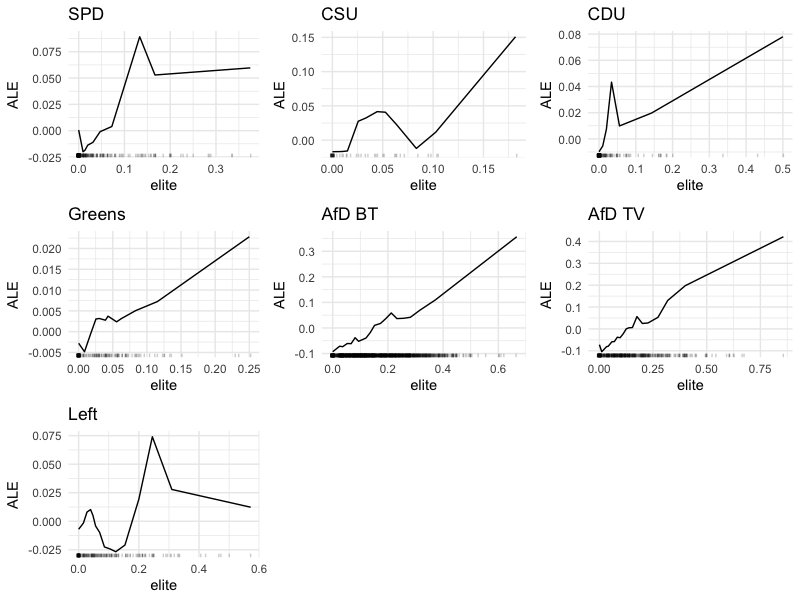

In [10]:
ggarrange(plotlist=plots)